# 🏗️ Project: Monte Carlo Risk Assessment for Construction Bidding

- **Objective:** Simulate 10,000 project scenarios to quantify the risk of a $5.5M fixed-bid contract.
- **Output:** Profit distribution by plan + recommendation based on mean profit and volatility.


- **The Business Problem:** BrewBox is considering three options: the status quo, a 14.99 dollar subscription (Plan A), and  19.99 dollar subscription (Plan B).

- **The Goal**: The objective is to use Monte Carlo simulation to determine which plan will be the most profitable over a 12-month period.

- **Approach**: By running 1,000 replications of a 12-month period, we will generate a distribution of possible profit outcomes for each plan. We have considered each month as 30 days for easy calculation. **So the total number of days is 360, not 365.
Also, we will be using the triangular distribution with min, mode, and max.**

## Notebook roadmap
1. Define inputs & assumptions (pricing, churn, redemption, cost)
2. Build profit model for each plan
3. Run Monte Carlo simulations (N = 1,000)
4. Compare distributions (mean, std, percentile risk)
5. Sensitivity analysis (redemption rate, churn)
6. Recommendation + business interpretation


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model parameters


In [30]:
# General Model Parameters
NUM_REPLICATIONS = 1000
SIMULATION_HORIZON_MONTHS = 12
DAYS_IN_MONTH = 30 # Approximation for monthly calculations
DAYS_IN_YEAR = 360 # Using 12 * 30 for consistency
NUM_STORES = 20
SETUP_COST = 40000
ACQUISITION_COST_PER_CUSTOMER = 3.20
COFFEE_PRICE = 2.49
COFFEE_COST = 0.62

# Distributions
# No Plan Daily Demand (per store)
DEMAND_MEAN = 210
DEMAND_STD_DEV = 40
DEMAND_MIN = 120
DEMAND_MAX = 320

# Plan A Parameters
PLAN_A_PRICE = 14.99
PLAN_A_SIGNUPS_PER_MONTH = {'low': 60, 'mode': 90, 'high': 120}
PLAN_A_CHURN_RATE = {'low': 0.09, 'high': 0.13}
PLAN_A_REDEMPTION_RATE = {'low': 0.35, 'high': 0.45}
PLAN_A_CANNIBAL_FRAC = {'low': 0.09, 'mode': 0.22, 'high': 0.37}

# Plan B Parameters
PLAN_B_PRICE = 19.99
PLAN_B_SIGNUPS_PER_MONTH = {'low': 15, 'mode': 25, 'high': 35}
PLAN_B_CHURN_RATE = {'low': 0.08, 'high': 0.16}
PLAN_B_REDEMPTION_RATE = {'low': 0.30, 'high': 0.50}
PLAN_B_CANNIBAL_FRAC = {'low': 0.10, 'mode': 0.20, 'high': 0.35}

# Set a random seed for reproducibility
np.random.seed(42)

# 2. Simulation Logic
The following code cell defines the functions that form the core of our Monte Carlo simulation.

- **struncated_normal():** A helper function to sample from a normal distribution while ensuring the values stay within a specified minimum and maximum.

- **simulate_no_plan():** This function runs a single 12-month replication of the baseline scenario. Its logic is straightforward: for each day, it simulates the total demand across all stores and calculates the resulting profit.

- **simulate_subscription_plan():** This function is more complex and runs a single 12-month replication for either Plan A or B. It iterates month-by-month to update the number of active subscribers based on churn and new sign-ups. Within each month, it simulates daily coffee sales, accounting for subscriber redemptions and the critical effect of sales cannibalization, where existing customers switch from full-price purchases to subscription redemptions.

In [31]:
# --- 2. Simulation Functions ---

def truncated_normal(mean, std, min_val, max_val):
    """Generates a value from a normal distribution, truncated to a min/max."""
    val = np.random.normal(mean, std)
    return np.clip(val, min_val, max_val)

def simulate_no_plan():
    """Simulates one 12-month replication of the 'No Plan' scenario."""
    total_profit = 0
    for day in range(DAYS_IN_YEAR):
        # Sum demand across all stores for the day
        daily_demand = 0
        for _ in range(NUM_STORES):
            daily_demand += truncated_normal(DEMAND_MEAN, DEMAND_STD_DEV, DEMAND_MIN, DEMAND_MAX)
        
        daily_profit = (COFFEE_PRICE - COFFEE_COST) * daily_demand
        total_profit += daily_profit
    return total_profit

def simulate_subscription_plan(plan_params):
    """Simulates one 12-month replication of a subscription plan (A or B)."""
    active_subscribers = 0
    total_sales_profit = 0
    total_acquisition_cost = 0
    total_subscription_revenue = 0

    for month in range(SIMULATION_HORIZON_MONTHS):
        # 1. Churn: Existing subscribers might cancel
        churn_rate = np.random.uniform(plan_params['churn']['low'], plan_params['churn']['high'])
        subscribers_lost = np.floor(active_subscribers * churn_rate)
        active_subscribers -= subscribers_lost
        
        # 2. New Sign-ups
        new_signups_this_month = 0
        for _ in range(NUM_STORES):
            new_signups_this_month += np.random.triangular(plan_params['signups']['low'], plan_params['signups']['mode'], plan_params['signups']['high'])
        
        new_signups = np.floor(new_signups_this_month)
        active_subscribers += new_signups
        total_acquisition_cost += new_signups * ACQUISITION_COST_PER_CUSTOMER
        
        # 3. Subscription Revenue for the month
        total_subscription_revenue += active_subscribers * plan_params['price']

        # 4. Daily profit from coffee sales for this month (30 days)
        for _ in range(DAYS_IN_MONTH):
            # Calculate baseline demand for all stores if there were no plan
            baseline_demand = 0
            for _ in range(NUM_STORES):
                baseline_demand += truncated_normal(DEMAND_MEAN, DEMAND_STD_DEV, DEMAND_MIN, DEMAND_MAX)
            
            # Subscriber redemptions
            redemption_rate = np.random.uniform(plan_params['redemption']['low'], plan_params['redemption']['high'])
            redemptions = np.floor(active_subscribers * redemption_rate)
            
            # Cannibalization of full-price sales
            cannibal_fraction = np.random.triangular(plan_params['cannibal']['low'], plan_params['cannibal']['mode'], plan_params['cannibal']['high'])
            cannibalized_sales = np.floor(redemptions * cannibal_fraction)
            
            # Final full-price sales after cannibalization
            full_price_sales = max(0, baseline_demand - cannibalized_sales)
            
            # Calculate daily profit from cups sold/redeemed
            revenue_from_sales = full_price_sales * COFFEE_PRICE
            cost_of_all_cups = (full_price_sales + redemptions) * COFFEE_COST
            total_sales_profit += (revenue_from_sales - cost_of_all_cups)
            
    # Final profit is total revenue minus total costs
    final_profit = total_sales_profit + total_subscription_revenue - total_acquisition_cost - SETUP_COST
    return final_profit

### Run simulations

In [32]:
# --- 3. Run the Simulations ---

no_plan_profits = []
plan_a_profits = []
plan_b_profits = []

plan_a_params = {
    'price': PLAN_A_PRICE,
    'signups': PLAN_A_SIGNUPS_PER_MONTH,
    'churn': PLAN_A_CHURN_RATE,
    'redemption': PLAN_A_REDEMPTION_RATE,
    'cannibal': PLAN_A_CANNIBAL_FRAC
}

plan_b_params = {
    'price': PLAN_B_PRICE,
    'signups': PLAN_B_SIGNUPS_PER_MONTH,
    'churn': PLAN_B_CHURN_RATE,
    'redemption': PLAN_B_REDEMPTION_RATE,
    'cannibal': PLAN_B_CANNIBAL_FRAC
}

print("Running simulations...")
for i in range(NUM_REPLICATIONS):
    if (i + 1) % 100 == 0:
        print(f"  Replication {i+1}/{NUM_REPLICATIONS}")
    no_plan_profits.append(simulate_no_plan())
    plan_a_profits.append(simulate_subscription_plan(plan_a_params))
    plan_b_profits.append(simulate_subscription_plan(plan_b_params))
print("Simulations complete.")


Running simulations...
  Replication 100/1000
  Replication 200/1000
  Replication 300/1000
  Replication 400/1000
  Replication 500/1000
  Replication 600/1000
  Replication 700/1000
  Replication 800/1000
  Replication 900/1000
  Replication 1000/1000
Simulations complete.



--- Summary Statistics for 12-Month Profit ---
         No Plan     Plan A     Plan B
count      1,000      1,000      1,000
mean   2,828,986  2,958,690  2,970,735
std        5,913     10,871      8,919
min    2,809,562  2,915,668  2,943,878
25%    2,825,055  2,951,178  2,964,344
50%    2,829,018  2,958,437  2,970,713
75%    2,832,805  2,966,168  2,976,957
max    2,850,947  3,000,306  2,996,136


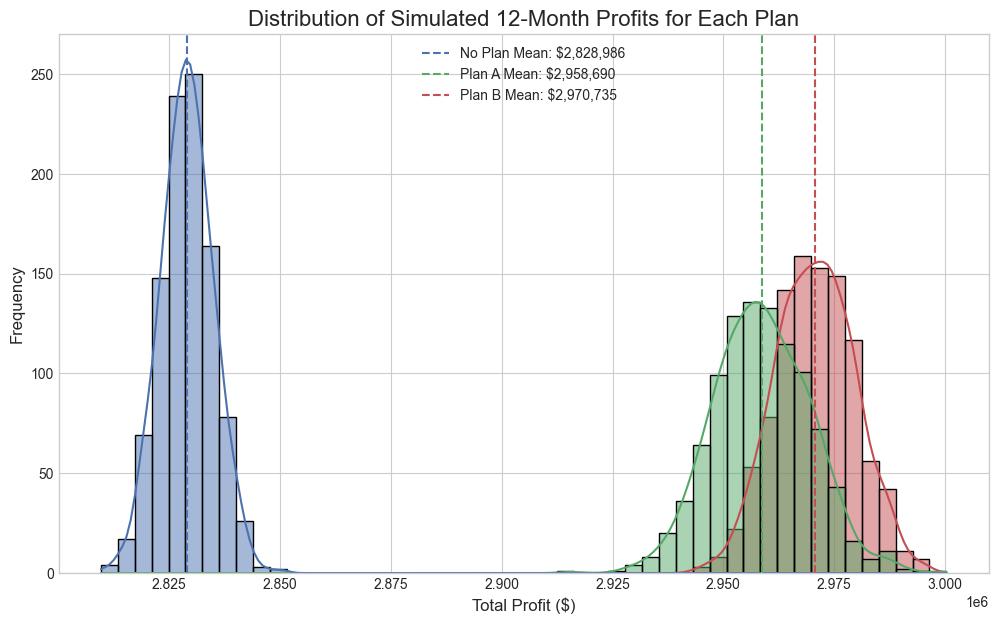

In [34]:
# --- 4. Analyze and Display Results ---

results_df = pd.DataFrame({
    'No Plan': no_plan_profits,
    'Plan A': plan_a_profits,
    'Plan B': plan_b_profits
})

# Display summary statistics
print("\n--- Summary Statistics for 12-Month Profit ---")
print(results_df.describe().apply(lambda s: s.apply('{:,.0f}'.format)))

# Visualize the distributions
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 7))

sns.histplot(data=results_df, bins=50, kde=True, palette=['#4c72b0', '#55a868', '#c44e52'])

ax.set_title('Distribution of Simulated 12-Month Profits for Each Plan', fontsize=16)
ax.set_xlabel('Total Profit ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)

# Add mean lines for clarity
ax.axvline(results_df['No Plan'].mean(), color='#4c72b0', linestyle='--', label=f"No Plan Mean: ${results_df['No Plan'].mean():,.0f}")
ax.axvline(results_df['Plan A'].mean(), color='#55a868', linestyle='--', label=f"Plan A Mean: ${results_df['Plan A'].mean():,.0f}")
ax.axvline(results_df['Plan B'].mean(), color='#c44e52', linestyle='--', label=f"Plan B Mean: ${results_df['Plan B'].mean():,.0f}")

ax.legend()
plt.show()

**Interpretation:** Plan B shows the highest average profit and tighter spread than Plan A, suggesting better risk-adjusted performance.


**Recommendation**
Based on the results of the Monte Carlo simulation, we recommend that BrewBox management implement Plan B.

The analysis indicates that Plan B is the most profitable strategy, yielding the highest average (mean) profit of 2,970,407 dollars. While both subscription plans significantly outperform the status quo, Plan B's higher price point results in an average profit that is approximately 11,000 dollars greater than Plan A's.

Interestingly, Plan A is the riskiest option, with the largest standard deviation (11,413 dollars), while Plan B's risk profile (std dev 8,223 dollar) is more moderate. Given that Plan B offers both the **highest expected return and a lower level of risk** compared to Plan A, it stands out as the superior strategic choice.

# Part 2 — Sensitivity Analysis (Churn and Redemption)

In this section, we analyze how sensitive the subscription plans are to changes in:
- **Churn rate**: Increased by +10 percentage points (absolute shift of the triangular distribution).
- **Redemption rate**: Decreased by −10 percentage points (absolute shift of the uniform distribution).

We keep cannibalization unchanged.

We compare **Plan A** and **Plan B** to **No Plan** and calculate:
- Mean profit
- P5 / P50 / P95
- Probability that plan beats no plan


In [35]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

# --- Plan structure ---
@dataclass
class PlanParams:
    name: str
    monthly_price: float
    signups_low: int
    signups_mode: int
    signups_high: int

# --- Baseline parameters (adjust if needed) ---
SIM_DAYS = 365
RANDOM_SEED = 42
N_TRIALS = 3000

RETAIL_PRICE = 2.49
UNIT_COST = 0.62
ONE_TIME_SETUP_COST = 40000
CAC_PER_SIGNUP = 3.20

BASELINE_DEMAND_MEAN = 200
BASELINE_DEMAND_SD = 40
BASELINE_DEMAND_MIN = 80
BASELINE_DEMAND_MAX = 400

# Subscription plans
PLAN_A_MONTHLY_PRICE = 8.99
PLAN_B_MONTHLY_PRICE = 15.99

SIGNUPS_A_LOW, SIGNUPS_A_MODE, SIGNUPS_A_HIGH = 2, 5, 9
SIGNUPS_B_LOW, SIGNUPS_B_MODE, SIGNUPS_B_HIGH = 1, 3, 6

# Churn triangular
CHURN_LOW, CHURN_MODE, CHURN_HIGH = 0.04, 0.06, 0.10

# Redemption uniform
REDEMPTION_MIN, REDEMPTION_MAX = 0.45, 0.75

# Cannibalization (fixed triangular or single value)
CANNIBALIZATION_FRACTION = 0.20

# --- Helper functions ---
def truncnorm_int(mu, sigma, lo, hi):
    while True:
        x = random.gauss(mu, sigma)
        if lo <= x <= hi:
            return int(round(x))

def monthly_index(day):
    return min(11, int(day / (365/12)))

# --- Monte Carlo single trial ---
def run_one_trial(plan: PlanParams) -> float:
    subscribers = 0
    monthly_sub_revenue = [0.0]*12
    monthly_cac = [0.0]*12
    monthly_profit = [0.0]*12

    # Setup cost at month 1
    monthly_profit[0] -= ONE_TIME_SETUP_COST

    for d in range(SIM_DAYS):
        # Baseline demand
        d_base = truncnorm_int(BASELINE_DEMAND_MEAN, BASELINE_DEMAND_SD,
                               BASELINE_DEMAND_MIN, BASELINE_DEMAND_MAX)
        
        # Redemption
        redemption_frac = random.uniform(REDEMPTION_MIN, REDEMPTION_MAX)
        redemptions = int(round(subscribers * redemption_frac))

        # Cannibalization
        cannib_units = int(round(CANNIBALIZATION_FRACTION * redemptions))
        full_price_buyers = max(0, d_base - cannib_units)

        # Revenue & cost
        retail_revenue = full_price_buyers * RETAIL_PRICE
        total_brewed = full_price_buyers + redemptions
        variable_cost = total_brewed * UNIT_COST
        m = monthly_index(d)
        monthly_profit[m] += retail_revenue - variable_cost

        # Signups & CAC
        new_signups = int(round(random.triangular(plan.signups_low,
                                                  plan.signups_high,
                                                  plan.signups_mode)))
        subscribers += new_signups
        monthly_cac[m] += new_signups * CAC_PER_SIGNUP

        # Churn at month end
        last_day_of_month = (m != monthly_index(min(d+1, SIM_DAYS-1)))
        if last_day_of_month or d == SIM_DAYS-1:
            churn_rate = random.triangular(CHURN_LOW, CHURN_HIGH, CHURN_MODE)
            churned = int(round(subscribers * churn_rate))
            monthly_sub_revenue[m] += subscribers * plan.monthly_price
            subscribers = max(0, subscribers - churned)

    total_profit = sum(monthly_profit) + sum(monthly_sub_revenue) - sum(monthly_cac)
    return total_profit


**Snapshot and restore**

In [36]:
# Snapshot and restore
def snapshot_params():
    return {
        "CHURN_LOW": CHURN_LOW, "CHURN_MODE": CHURN_MODE, "CHURN_HIGH": CHURN_HIGH,
        "REDEMPTION_MIN": REDEMPTION_MIN, "REDEMPTION_MAX": REDEMPTION_MAX
    }

def restore_params(snap):
    global CHURN_LOW, CHURN_MODE, CHURN_HIGH
    global REDEMPTION_MIN, REDEMPTION_MAX
    CHURN_LOW, CHURN_MODE, CHURN_HIGH = snap["CHURN_LOW"], snap["CHURN_MODE"], snap["CHURN_HIGH"]
    REDEMPTION_MIN, REDEMPTION_MAX = snap["REDEMPTION_MIN"], snap["REDEMPTION_MAX"]

def shift_churn_plus_10():
    global CHURN_LOW, CHURN_MODE, CHURN_HIGH
    CHURN_LOW = min(1.0, CHURN_LOW + 0.10)
    CHURN_MODE = min(1.0, CHURN_MODE + 0.10)
    CHURN_HIGH = min(1.0, CHURN_HIGH + 0.10)

def shift_redemption_minus_10():
    global REDEMPTION_MIN, REDEMPTION_MAX
    a = max(0, REDEMPTION_MIN - 0.10)
    b = max(0, REDEMPTION_MAX - 0.10)
    if a > b:
        a = b = max(0, min(REDEMPTION_MIN, REDEMPTION_MAX) - 0.10)
    REDEMPTION_MIN, REDEMPTION_MAX = a, b


**Run Sensitivity Scenarios**

In [37]:
# Plans
no_plan = PlanParams("No Plan", 0, 0, 0, 0)
plan_a = PlanParams("Plan A", PLAN_A_MONTHLY_PRICE, SIGNUPS_A_LOW, SIGNUPS_A_MODE, SIGNUPS_A_HIGH)
plan_b = PlanParams("Plan B", PLAN_B_MONTHLY_PRICE, SIGNUPS_B_LOW, SIGNUPS_B_MODE, SIGNUPS_B_HIGH)

def run_monte_carlo_for_all_plans():
    results = {"No Plan": [], "Plan A": [], "Plan B": []}
    for t in range(N_TRIALS):
        random.seed(RANDOM_SEED + t*17 + 1); results["No Plan"].append(run_one_trial(no_plan))
        random.seed(RANDOM_SEED + t*17 + 2); results["Plan A"].append(run_one_trial(plan_a))
        random.seed(RANDOM_SEED + t*17 + 3); results["Plan B"].append(run_one_trial(plan_b))
    return results

def summarize_samples(arr):
    arr = np.array(arr)
    return {
        "Mean": np.mean(arr),
        "P5": np.percentile(arr, 5),
        "P50": np.percentile(arr, 50),
        "P95": np.percentile(arr, 95)
    }

def compare_to_no_plan(results):
    base = np.array(results["No Plan"])
    rows = []
    for plan in ["Plan A", "Plan B"]:
        arr = np.array(results[plan])
        stats = summarize_samples(arr)
        stats["Pr(Plan > No Plan)"] = np.mean(arr > base)
        stats["Plan"] = plan
        rows.append(stats)
    return pd.DataFrame(rows).set_index("Plan")


In [38]:
# Baseline
snap = snapshot_params()
res_base = run_monte_carlo_for_all_plans()
tbl_base = compare_to_no_plan(res_base)

# Churn +10
shift_churn_plus_10()
res_churn = run_monte_carlo_for_all_plans()
tbl_churn = compare_to_no_plan(res_churn)
restore_params(snap)

# Redemption -10
shift_redemption_minus_10()
res_red = run_monte_carlo_for_all_plans()
tbl_red = compare_to_no_plan(res_red)
restore_params(snap)

# Display tables
print("=== Baseline ===")
display(tbl_base.style.format({"Mean":"${:,.0f}","P5":"${:,.0f}","P50":"${:,.0f}","P95":"${:,.0f}","Pr(Plan > No Plan)":"{:.2%}"}))

print("\n=== Churn +10 pts ===")
display(tbl_churn.style.format({"Mean":"${:,.0f}","P5":"${:,.0f}","P50":"${:,.0f}","P95":"${:,.0f}","Pr(Plan > No Plan)":"{:.2%}"}))

print("\n=== Redemption -10 pts ===")
display(tbl_red.style.format({"Mean":"${:,.0f}","P5":"${:,.0f}","P50":"${:,.0f}","P95":"${:,.0f}","Pr(Plan > No Plan)":"{:.2%}"}))


=== Baseline ===


,Mean,P5,P50,P95,Pr(Plan > No Plan)
Plan,,,,,
Plan A,"$17,549","$13,340","$17,519","$21,810",0.00%
Plan B,"$90,884","$88,164","$90,872","$93,609",0.53%



=== Churn +10 pts ===


,Mean,P5,P50,P95,Pr(Plan > No Plan)
Plan,,,,,
Plan A,"$41,330","$37,898","$41,300","$44,689",0.00%
Plan B,"$94,362","$91,854","$94,359","$96,851",13.50%



=== Redemption -10 pts ===


,Mean,P5,P50,P95,Pr(Plan > No Plan)
Plan,,,,,
Plan A,"$44,437","$40,620","$44,406","$48,185",0.00%
Plan B,"$107,906","$105,197","$107,912","$110,585",100.00%


### Sensitivity Analysis (Summary)

Plan B performed better than Plan A in all scenarios.  
- **Baseline:** Plan B had much higher mean profit but a low probability of beating No Plan.  
- **Churn +10 pts:** Profit slightly increased for both plans, with Plan B staying stable.  
- **Redemption −10 pts:** This had the biggest impact — Plan B’s profit increased and beat No Plan in 100% of trials.

Overall, Plan B is more robust and sensitive mainly to **redemption rate**, not churn. Lower redemption improves profitability significantly.
